In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

train_check = pd.read_csv("/kaggle/input/datasets/rishta123/tamil-text/trainV2.csv")
print(f"Train size: {len(train_check)}")
print(train_check.head(3))

Train size: 3652
                                                Text        Class
0  நான் கூட உன்னை வெகுளியான பொண்ணு&#39;னு நெனச்சி...  Non-Abusive
1  உன் போட்டோவை டாய்லெட்டுக்கு மாற்றினார்கள் அசிங...      Abusive
2  கண்டா வரச்சொல்லுங்க கார்த்திய திவ்யாவோட சேர்த்...  Non-Abusive


In [2]:
print(f"Original Label distribution:\n{train_check['Class'].value_counts()}")

Original Label distribution:
Class
Non-Abusive    1883
Abusive        1768
abusive           1
Name: count, dtype: int64


In [3]:
# Normalize labels to ensure consistency
train_check["Class"] = train_check["Class"].str.strip().str.lower().map({
    "abusive":     "Abusive",
    "non-abusive": "Non-Abusive"
})

print(f"Normalized distribution:\n{train_check['Class'].value_counts()}")
true_labels_train = train_check["Class"].values

Normalized distribution:
Class
Non-Abusive    1883
Abusive        1769
Name: count, dtype: int64


In [4]:
# Load the predictions
ensemble_pred = pd.read_csv('/kaggle/input/datasets/rishta123/ensemble/CUET_Synthetica_FINAL_ENSEMBLE_12models.csv')

print(f"Total predictions: {len(ensemble_pred)}")
label_col = 'Class' if 'Class' in ensemble_pred.columns else 'label'
print(f"Using prediction column: '{label_col}'")

Total predictions: 913
Using prediction column: 'Class'


In [5]:
# Load the actual ground truth for the test set
dev_with_labels = pd.read_csv('/kaggle/input/datasets/rishta123/testdataset/test_with_labels.csv')

# Get ground truth and convert to numbers for sklearn
y_true = (dev_with_labels['Class'].str.strip().str.lower() == 'abusive').astype(int)

# Get predictions and convert to numbers
y_pred = (ensemble_pred[label_col].str.strip().str.lower() == 'abusive').astype(int)

# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print("ENSEMBLE MODEL PERFORMANCE")
print(f"Accuracy:  {accuracy:.4f}")
print(f"F1-Score:  {f1:.4f}")

ENSEMBLE MODEL PERFORMANCE
Accuracy:  0.8094
F1-Score:  0.8086


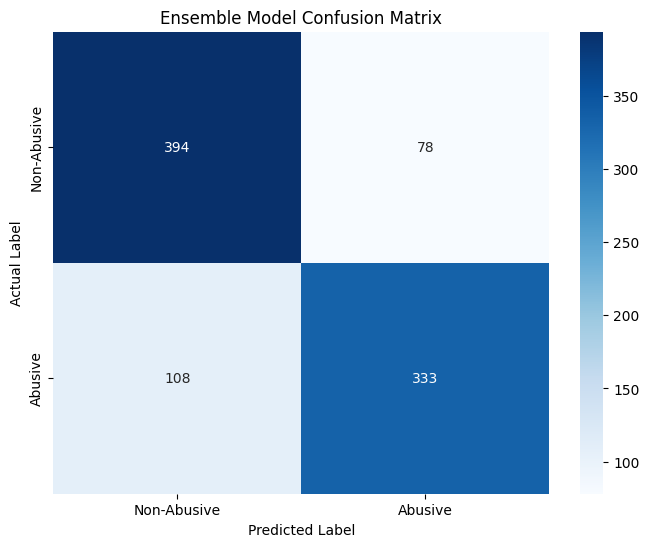

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate the matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=["Non-Abusive", "Abusive"], 
            yticklabels=["Non-Abusive", "Abusive"])

plt.title('Ensemble Model Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')


plt.savefig('confusion_matrix_ensemble.png', dpi=300, bbox_inches='tight')

plt.show()

In [7]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score



test_labels_path = '/kaggle/input/datasets/rishta123/testdataset/test_with_labels.csv'
dev_with_labels = pd.read_csv(test_labels_path)

# Normalize Ground Truth: 1 for Abusive, 0 for Non-Abusive
y_true = (dev_with_labels['Class'].str.strip().str.lower() == 'abusive').astype(int)

# 2. Define the directory containing all your prediction CSVs
ensemble_dir = '/kaggle/input/datasets/rishta123/submission'
prediction_files = [f for f in os.listdir(ensemble_dir) if f.endswith('.csv')]

# 3. Loop through all files and calculate metrics
results = []

for file_name in prediction_files:
    file_path = os.path.join(ensemble_dir, file_name)
    df_pred = pd.read_csv(file_path)
    
    # Identify the correct column (usually 'Class' or 'label')
    label_col = 'Class' if 'Class' in df_pred.columns else 'label'
    
    # Normalize Predictions: 1 for Abusive, 0 for Non-Abusive
    y_pred = (df_pred[label_col].str.strip().str.lower() == 'abusive').astype(int)
    
    # Check for size mismatch before calculating
    if len(y_pred) != len(y_true):
        print(f"Skipping {file_name}: Size mismatch ({len(y_pred)} vs {len(y_true)})")
        continue
        
    # Calculate Metrics
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')
    prec = precision_score(y_true, y_pred, average='macro')
    rec = recall_score(y_true, y_pred, average='macro')
    
    results.append({
        "Model File": file_name,
        "Accuracy": round(acc, 4),
        "F1-Score": round(f1, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4)
    })

# 4. Display the Final Comparison Table
results_df = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)
print("--- ALL MODELS PERFORMANCE COMPARISON ---")
display(results_df)

--- ALL MODELS PERFORMANCE COMPARISON ---


,Model File,Accuracy,F1-Score,Precision,Recall
5,CUET_Synthetica_FINAL_ENSEMBLE_12models.csv,0.8094,0.8086,0.8106,0.8082
3,CUET_Synthetica_IndicBERT_42_2.csv,0.8083,0.8075,0.8096,0.8070
1,CUET_Synthetica_IndicBERT_3407_1.csv,0.8072,0.8055,0.8119,0.8050
10,CUET_Synthetica_IndicBERT_42_3.csv,0.7985,0.7976,0.7996,0.7972
0,CUET_Synthetica_IndicBERT_42_4.csv,0.7974,0.7964,0.7987,0.7960
12,CUET_Synthetica_MuRIL_3407_3_.csv,0.7963,0.7954,0.7975,0.7949
7,CUET_Synthetica_MuRIL_3407_4.csv,0.7941,0.7935,0.7943,0.7933
2,CUET_Synthetica_XLMRobertaLarge_3407_3.csv,0.7919,0.7915,0.7919,0.7913
4,CUET_Synthetica_XLMRobertaLarge_3407_2.csv,0.7897,0.7893,0.7897,0.7891
11,CUET_Synthetica_XLMRobertaLarge_3407_1.csv,0.7886,0.7882,0.7885,0.7881
